# Worshop 06: Análisis Multicriterio
## Por: Juan Camilo Aros, Alma Wettig, Jeanneth Vallejo

El presente análisis tuvo como objetivo diseñar un corredor ecológico para el jaguar (Panthera onca), una especie en peligro de extinción, en el departamento de Antioquia. Para ello, se implementó un análisis multicriterio espacial que integró información ecológica, social y físico-ambiental, evaluada desde tres perspectivas: conservacionista, equilibrada y precautoria. Cada una de estas perspectivas ponderó de forma diferenciada variables como áreas protegidas, ecosistemas, comunidades étnicas, centros poblados, cuerpos de agua, pendiente y elevación, con el fin de identificar las zonas más aptas para la conectividad del hábitat del jaguar. Posteriormente, se generó un mapa promedio de las tres perspectivas y, a partir de este, se determinó la ruta más viable entre las dos principales áreas de presencia del felino, siguiendo los pixeles de mayor aptitud sin aplicar restricciones excesivas, lo cual permitió una propuesta de conectividad realista y ecológicamente coherente.

# 1.Unificar diferentes capas en un solo raster de "Cuerpos de agua"

Este código convierte múltiples archivos shapefile de cuerpos de agua en un solo archivo raster. Para ello, une todas las geometrías, define la resolución espacial y genera un raster en el que los píxeles con cuerpos de agua reciben el valor 1. Finalmente, guarda el resultado en formato GeoTIFF dentro de la misma carpeta.

In [1]:
import os
import glob
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from shapely.ops import unary_union

# Pedir ruta de carpeta al usuario
carpeta = "/app/WORKSHOP06/DATOS/AGUA"

if not os.path.isdir(carpeta):
    raise ValueError("La ruta no es válida.")

# Buscar todos los .shp
rutas_shapefiles = glob.glob(os.path.join(carpeta, "*.shp"))

if len(rutas_shapefiles) == 0:
    raise ValueError("No se encontraron archivos .shp en la carpeta.")

# Leer y unir todos los shapes
gdf_total = gpd.GeoDataFrame(pd.concat([gpd.read_file(shp) for shp in rutas_shapefiles], ignore_index=True))

# Definir CRS (por seguridad)
if gdf_total.crs is None:
    raise ValueError("Los shapefiles no tienen sistema de coordenadas definido (CRS).")

# Crear unión geométrica de todos los cuerpos de agua
geometria_unida = unary_union(gdf_total.geometry)

# Definir resolución (en unidades del CRS, usualmente metros)
resolucion = 10  

# Calcular bounds y tamaño del raster
minx, miny, maxx, maxy = geometria_unida.bounds
ancho = int((maxx - minx) / resolucion)
alto = int((maxy - miny) / resolucion)

# Transformación afín
from affine import Affine
transform = Affine.translation(minx, maxy) * Affine.scale(resolucion, -resolucion)

# Rasterizar geometría
raster = rasterize(
    [(geometria_unida, 1)],
    out_shape=(alto, ancho),
    transform=transform,
    fill=0,
    dtype='uint8'
)

# Guardar raster
salida = os.path.join(carpeta, "cuerpos_agua_raster.tif")

with rasterio.open(
    salida, "w",
    driver="GTiff",
    height=alto,
    width=ancho,
    count=1,
    dtype=raster.dtype,
    crs=gdf_total.crs,
    transform=transform,
    nodata=0
) as dst:
    dst.write(raster, 1)

print(f"Raster guardado en: {salida}")

Raster guardado en: /app/WORKSHOP06/DATOS/AGUA/cuerpos_agua_raster.tif


# 2.Crear stack con todas las variables

Este fragmento importa las librerías necesarias para trabajar con datos geoespaciales en formato vectorial y raster. Incluye herramientas para lectura, escritura, transformación y rasterización de archivos, así como manipulación de datos con pandas, numpy y geopandas, facilitando así la construcción de flujos de procesamiento espacial automatizados.

In [35]:
import os
import glob
import rasterio
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.transform import from_origin
from affine import Affine
import geopandas as gpd
import pandas as pd
import numpy as np

Se localizan los archivos shapefile y raster dentro de la carpeta de trabajo y se verifica que exista al menos uno de los dos; de lo contrario, se detiene el proceso con un mensaje de error.

In [2]:
# Ruta a carpeta de entrada
carpeta = "/app/WORKSHOP06/DATOS" 

# Buscar todos los archivos
shapefiles = glob.glob(os.path.join(carpeta, "*.shp"))
rasters = glob.glob(os.path.join(carpeta, "*.tif"))

if not rasters and not shapefiles:
    raise ValueError("No se encontraron shapefiles ni raster.")

Se toma el primer archivo raster como referencia para extraer su sistema de coordenadas, resolución espacial, dimensiones y otros parámetros necesarios para alinear y procesar correctamente los demás insumos raster.

In [3]:
# Usar el primer raster como referencia
ref_raster_path = rasters[0]
with rasterio.open(ref_raster_path) as ref:
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height
    ref_bounds = ref.bounds
    ref_res = ref.res
    ref_dtype = 'float32'

stack_bandas = []

Se recorren los shapefiles encontrados para rasterizarlos, asegurando que estén en el mismo sistema de referencia del raster base y corrigiendo posibles geometrías inválidas. Solo se procesan aquellos archivos con geometrías válidas y no vacías, y se convierte cada capa en una banda raster alineada, que se agrega al conjunto final (stack_bandas).

In [4]:

# Procesar shapefiles (rasterización)
for shp_path in shapefiles:
    print(f"Procesando: {os.path.basename(shp_path)}")
    
    try:
        gdf = gpd.read_file(shp_path, engine="fiona")
    except Exception as e:
        print(f"Error al leer {os.path.basename(shp_path)}: {e}")
        continue

    # Reproyectar al CRS del raster base
    if gdf.crs != ref_crs:
        gdf = gdf.to_crs(ref_crs)
    
    # Corregir geometrías inválidas
    gdf["geometry"] = gdf["geometry"].apply(
        lambda geom: geom.buffer(0) if geom is not None and not geom.is_valid else geom
    )
    
    # Filtrar geometrías válidas y no vacías
    gdf = gdf[
        gdf.geometry.notnull() &
        (~gdf.geometry.is_empty) &
        (gdf.is_valid)
    ]
    
    if len(gdf) == 0:
        print(f"Archivo vacío o inválido: {os.path.basename(shp_path)} — se omite.")
        continue
    
    # Preparar para rasterización
    geometries = [(geom, 1) for geom in gdf.geometry]
    
    raster = rasterize(
        geometries,
        out_shape=(ref_height, ref_width),
        transform=ref_transform,
        fill=0,
        dtype=ref_dtype
    )
    stack_bandas.append(raster)

Procesando: Areas_Protegidas.shp
Procesando: CentrosPoblados.shp
Procesando: Comunidad_Negra_Titulada.shp
Procesando: Ecosistemas.shp
Procesando: jaguar_antioquia.shp
Procesando: Resguardo_Indigena_Formalizado_05.shp
Procesando: Vias_ant.shp
Procesando: Zonas_Reservas_Campesinas.shp


Se procesan los archivos raster ajustando su resolución, tamaño o proyección si difieren del raster de referencia. Luego, se agregan sus bandas al conjunto general para construir un stack multibanda alineado y coherente.

In [5]:
# Procesar rasters (reescalar / reproyectar si es necesario)
for r_path in rasters:
    with rasterio.open(r_path) as src:
        if src.crs != ref_crs or src.transform != ref_transform or src.width != ref_width or src.height != ref_height:
            data = src.read(
                out_shape=(src.count, ref_height, ref_width),
                resampling=Resampling.bilinear
            )
        else:
            data = src.read()
        
        for b in range(data.shape[0]):
            stack_bandas.append(data[b])

# Crear stack multibanda
stack_bandas = np.array(stack_bandas)

Se guarda el conjunto de capas procesadas en un único archivo raster multibanda (stack_unificado.tif), conservando la proyección, resolución y dimensiones del raster de referencia.

In [6]:
# Guardar el raster final
output_path = os.path.join(carpeta, "stack_unificado.tif")

with rasterio.open(
    output_path,
    'w',
    driver='GTiff',
    height=ref_height,
    width=ref_width,
    count=stack_bandas.shape[0],
    dtype=ref_dtype,
    crs=ref_crs,
    transform=ref_transform
) as dst:
    for i in range(stack_bandas.shape[0]):
        dst.write(stack_bandas[i], i + 1)

print(f" Stack multibanda guardado en: {output_path}")

 Stack multibanda guardado en: /app/WORKSHOP06/DATOS/stack_unificado.tif


Este bloque muestra dos imágenes en una misma figura: una tabla con los criterios utilizados para el análisis del corredor ecológico y una imagen representativa del jaguar. Las imágenes se presentan lado a lado, sin ejes visibles, para complementar visualmente la interpretación del ejercicio.

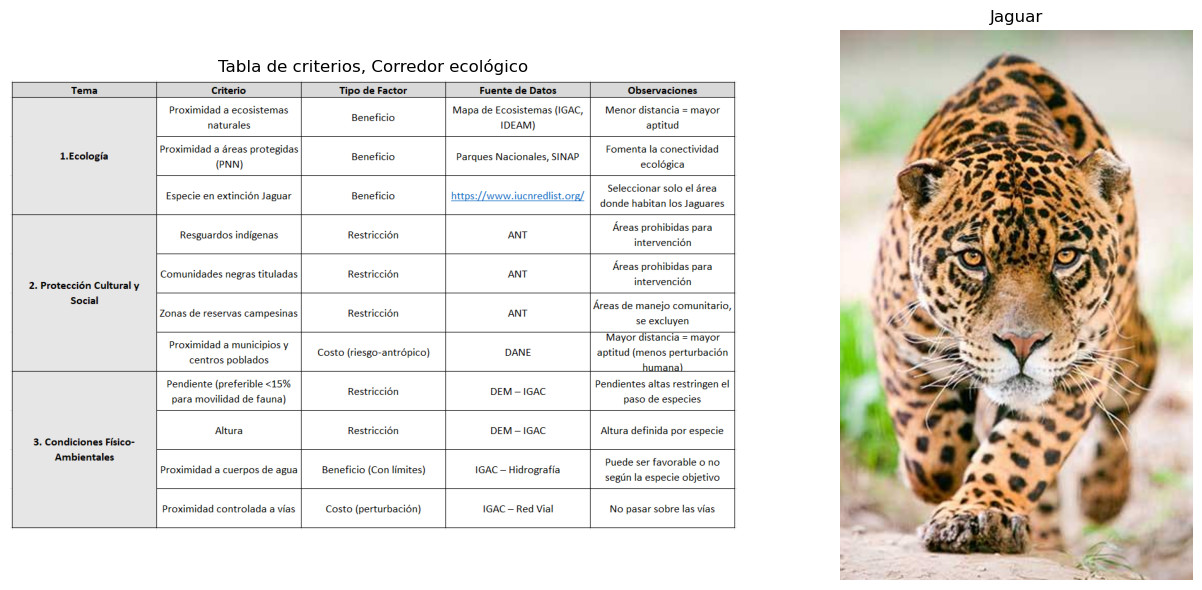

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Rutas a las imágenes
ruta_tabla = "/app/WORKSHOP06/DATOS/TABLA.png"
ruta_jaguar = "/app/WORKSHOP06/DATOS/JAGUAR.png"

# Leer imágenes
img_tabla = mpimg.imread(ruta_tabla)
img_jaguar = mpimg.imread(ruta_jaguar)

# Mostrar imágenes lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_tabla)
axes[0].axis("off")
axes[0].set_title("Tabla de criterios, Corredor ecológico")

axes[1].imshow(img_jaguar)
axes[1].axis("off")
axes[1].set_title("Jaguar")

plt.tight_layout()
plt.show()

# Análisis multicriterio para determinar un corredor ecológico para el Jaguar

En la línea de trabajo para desarrollar la actividad, se han trabajado tres rutas, donde las dos primeras no generaron los productos esperados para el análisis del caso de estudio, ya sea por inconsistencias en los resultados, limitaciones técnicas o por no cumplir con los criterios establecidos para la definición del corredor ecológico. Sin embargo, se incluyen como parte de la evidencia del proceso seguido, permitiendo demostrar la trazabilidad, iteración y toma de decisiones que condujeron al enfoque final más adecuado para el objetivo de conservación del jaguar.

# Primer ruta de trabajo (No definitiva)

Se accede al raster multibanda generado, se obtienen sus metadatos y se leen todas sus bandas para preparar la información que será utilizada en el análisis multicriterio.

In [37]:
stack_path = r"C:/Users/juanc/Documents/UN/GEOPROCESAMIENTO/GUIA/mi_proyecto_jupyter/WORKSHOP06/DATOS/stack_unificado.tif"
stack = rasterio.open(stack_path)
n_bandas = stack.count
meta = stack.meta
bandas = [stack.read(i + 1) for i in range(n_bandas)]

Se realiza una inspección del raster multibanda para visualizar sus características espaciales y estructurales, como dimensiones, número de bandas, sistema de referencia, resolución espacial, tipo de datos y extensión geográfica, asegurando que el archivo esté correctamente configurado para su uso en el análisis.

In [3]:
with rasterio.open(stack_path) as src:
    print(f"Ruta: {stack_path}")
    print(f"Driver: {src.driver}")
    print(f"Dimensiones (ancho x alto): {src.width} x {src.height}")
    print(f"Número de bandas: {src.count}")
    print(f"Sistema de referencia (CRS): {src.crs}")
    print(f"Unidad de CRS: {src.crs.linear_units}")
    print(f"Tipo de dato por banda: {src.dtypes}")
    print(f"Resolución (tamaño píxel): {src.res}")
    print(f"Tamaño de bloque: {src.block_shapes}")
    print(f"Extensión (bounds): {src.bounds}")
    print(f"Transformación afín:\n{src.transform}")

Ruta: /app/WORKSHOP06/DATOS/stack_unificado.tif
Driver: GTiff
Dimensiones (ancho x alto): 9366 x 10023
Número de bandas: 10
Sistema de referencia (CRS): ESRI:103599
Unidad de CRS: metre
Tipo de dato por banda: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32')
Resolución (tamaño píxel): (38.218514146914394, 38.21851414746087)
Tamaño de bloque: [(1, 9366), (1, 9366), (1, 9366), (1, 9366), (1, 9366), (1, 9366), (1, 9366), (1, 9366), (1, 9366), (1, 9366)]
Extensión (bounds): BoundingBox(left=4544727.989, bottom=2157232.4165, right=4902682.5925, top=2540296.5838)
Transformación afín:
| 38.22, 0.00, 4544727.99|
| 0.00,-38.22, 2540296.58|
| 0.00, 0.00, 1.00|


Se define un diccionario que asocia el nombre de cada criterio temático con el índice correspondiente a su banda en el raster multibanda, facilitando el acceso y organización de la información durante el análisis multicriterio.

In [4]:
criterios = {
    "Areas_Protegidas": 1,
    "CentrosPoblados": 2,
    "Comunidad_Negra_Titulada": 3,
    "Ecosistemas": 4,
    "jaguar_antioquia": 5,
    "Resguardo_Indigena_Formalizado_05": 6,
    "Vias_ant": 7,
    "Zonas_Reservas_Campesinas": 8,
    "DEM": 9,
    "CuerposAgua": 10
}

Se genera una visualización en cuadrícula de todas las bandas del raster multibanda, asignando a cada imagen su nombre temático correspondiente. Esto permite una inspección rápida del contenido espacial de cada criterio utilizado en el análisis multicriterio.

/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib/image.py:499: RuntimeWarning: overflow encountered in cast
  A_scaled /= ((a_max - a_min) / frac)
/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib/image.py:500: RuntimeWarning: overflow encountered in cast
  vrange /= ((a_max - a_min) / frac)
/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib/image.py:513: RuntimeWarning: overflow encountered in cast
  A_resampled *= ((a_max - a_min) / frac)
/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib/image.py:513: RuntimeWarning: invalid value encountered in multiply
  A_resampled *= ((a_max - a_min) / frac)
/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib/image.py:514: RuntimeWarning: overflow encountered in cast
  vrange *= ((a_max - a_min) / frac)
/opt/conda/envs/geo_env/lib/python3.9/site-packages/matplotlib/image.py:514: RuntimeWarning: invalid value encountered in multiply
  vrange *= ((a_max - a_min) / frac)


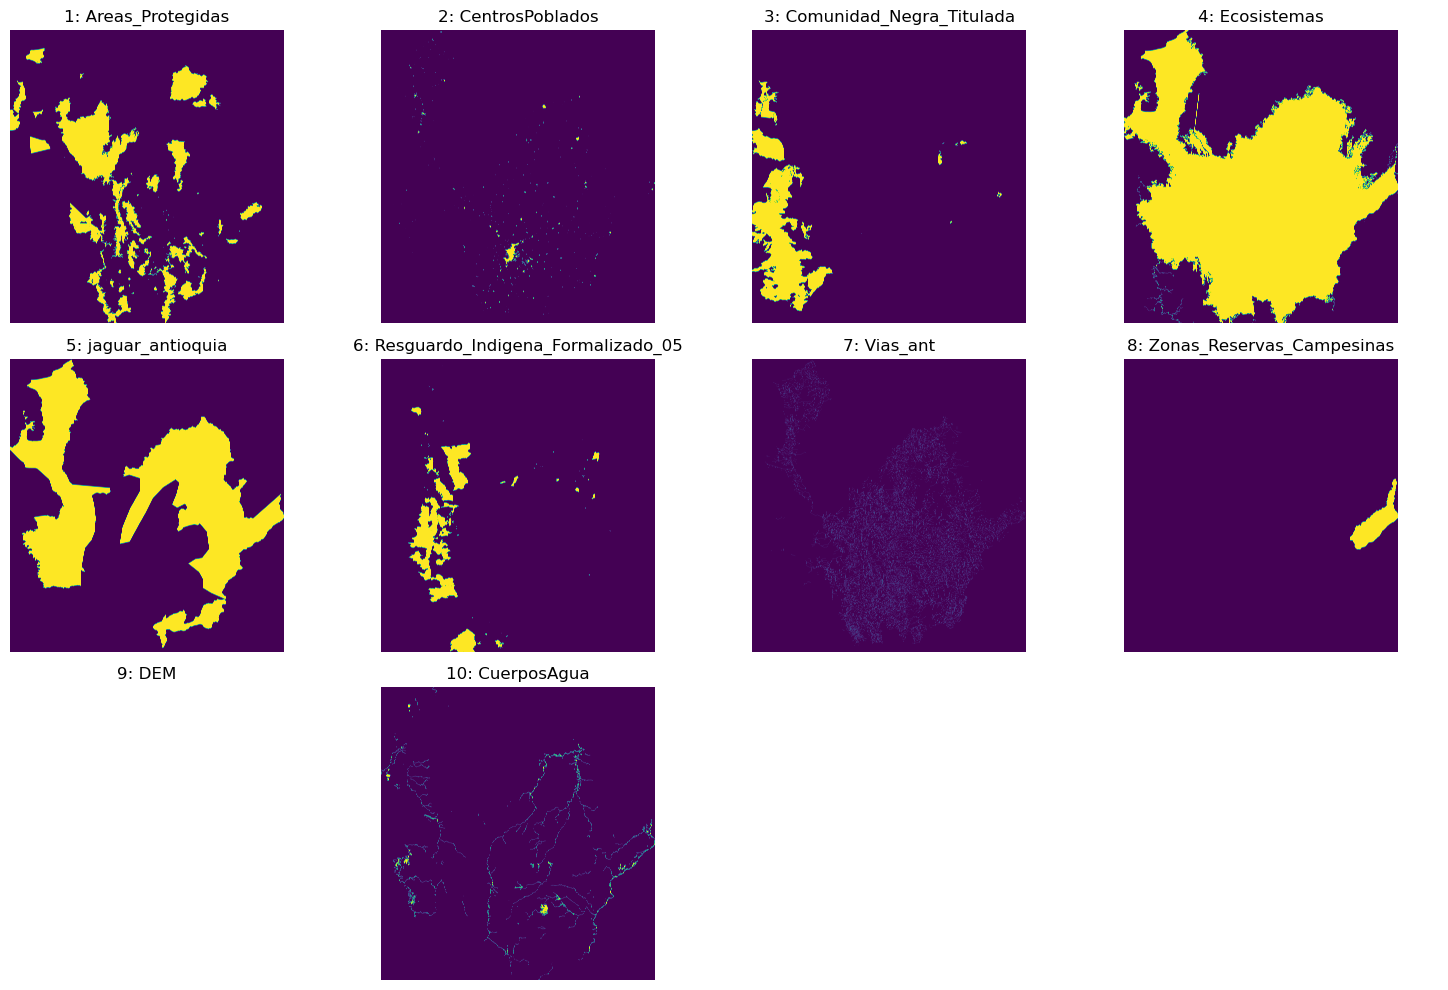

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import math
nombres = list(criterios.keys())

# Calcular dimensiones de la cuadrícula
cols = 4
rows = math.ceil(n_bandas / cols)

# Crear figura
fig, axs = plt.subplots(rows, cols, figsize=(15, 10))
axs = axs.flatten()

# Graficar cada banda
for i in range(n_bandas):
    axs[i].imshow(bandas[i], cmap='viridis')
    axs[i].set_title(f"{i+1}: {nombres[i]}")
    axs[i].axis('off')

# Eliminar subplots vacíos si hay
for j in range(n_bandas, len(axs)):
    axs[j].axis('off')

# Ajustar diseño
plt.tight_layout()
plt.show()

Se importan las librerías necesarias para trabajar con datos raster, manejar arreglos numéricos y generar visualizaciones, además de habilitar el uso de ventanas (`Window`) para procesar porciones específicas de un raster de forma eficiente.

In [6]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import Window

Se abre el raster multibanda `stack_unificado.tif` y se obtiene el número total de bandas contenidas, lo que permite preparar el análisis posterior sobre cada una de ellas.

In [7]:
stack_path = "/app/WORKSHOP06/DATOS/stack_unificado.tif"
stack = rasterio.open(stack_path)
n_bandas = stack.count

Se organizan las bandas del raster multibanda en un diccionario que asigna un nombre temático a cada índice, y luego se agrupan esos criterios en tres grandes categorías: **Ecología**, **Cultural y Social**, y **Físico-Ambiental**, lo que facilita la estructuración del análisis multicriterio según los enfoques definidos.

In [8]:
# Índices del stack
bandas_dict = {
    "Areas_Protegidas": 1,
    "CentrosPoblados": 2,
    "Comunidad_Negra_Titulada": 3,
    "Ecosistemas": 4,
    "jaguar_antioquia": 5,
    "Resguardo_Indigena_Formalizado_05": 6,
    "Vias_ant": 7,
    "Zonas_Reservas_Campesinas": 8,
    "DEM": 9,
    "CuerposAgua": 10
}

criterios = {
    "Ecología": ["jaguar_antioquia", "Ecosistemas", "DEM"],
    "CulturalSocial": ["Comunidad_Negra_Titulada", "Resguardo_Indigena_Formalizado_05", "Zonas_Reservas_Campesinas"],
    "FísicoAmbiental": ["Areas_Protegidas", "CentrosPoblados", "Vias_ant", "CuerposAgua"]
}

Se definen las ponderaciones asignadas a cada agrupación temática según tres perspectivas de análisis: **Conservacionista**, **Equilibrada** y de **Desarrollo**. Estas ponderaciones reflejan diferentes enfoques de priorización al momento de identificar las zonas más aptas para el corredor ecológico.

In [9]:
perspectivas = {
    "Conservacionista": {"Ecología": 0.6, "CulturalSocial": 0.3, "FísicoAmbiental": 0.1},
    "Equilibrada": {"Ecología": 0.4, "CulturalSocial": 0.3, "FísicoAmbiental": 0.3},
    "Desarrollo": {"Ecología": 0.2, "CulturalSocial": 0.2, "FísicoAmbiental": 0.6}
}

Se define una función que calcula mapas de aptitud por bloques para optimizar el procesamiento espacial. Utiliza los criterios agrupados por tema y sus bandas correspondientes, normaliza los valores de cada capa, promedia por grupo temático y aplica las ponderaciones establecidas en una perspectiva determinada. El resultado es un mapa continuo de aptitud generado de forma eficiente, bloque por bloque.

In [10]:
def normalizar(arr):
    arr = np.nan_to_num(arr, nan=0)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)

def calcular_por_tema_bloques(stack_path, criterios, bandas_dict, pesos_tema, block_size=512):
    with rasterio.open(stack_path) as src:
        height, width = src.height, src.width
        resultado = np.zeros((height, width), dtype=np.float32)

        for row in range(0, height, block_size):
            for col in range(0, width, block_size):
                win = Window(col, row, min(block_size, width - col), min(block_size, height - row))
                tema_layers = {}

                for tema, subcriterios in criterios.items():
                    capas = []
                    for crit in subcriterios:
                        idx = bandas_dict[crit]
                        capa = src.read(idx, window=win).astype(np.float32)
                        capa = normalizar(capa)
                        capas.append(capa)
                    tema_layers[tema] = np.mean(capas, axis=0)
                
                bloque_resultado = sum(pesos_tema[t] * tema_layers[t] for t in tema_layers)
                resultado[row:row+win.height, col:col+win.width] = bloque_resultado
    return resultado

Se generan los mapas de aptitud para cada una de las perspectivas definidas (Conservacionista, Equilibrada y Desarrollo) aplicando la función de cálculo por bloques. Cada resultado se guarda en un diccionario con el nombre de la perspectiva como clave.

In [11]:
resultados = {
    nombre: calcular_por_tema_bloques(stack_path, criterios, bandas_dict, pesos)
    for nombre, pesos in perspectivas.items()
}

Se visualizan los mapas de aptitud generados para cada perspectiva (Conservacionista, Equilibrada y Desarrollo) en una figura con tres paneles, permitiendo comparar de forma clara las diferencias espaciales según el enfoque aplicado.

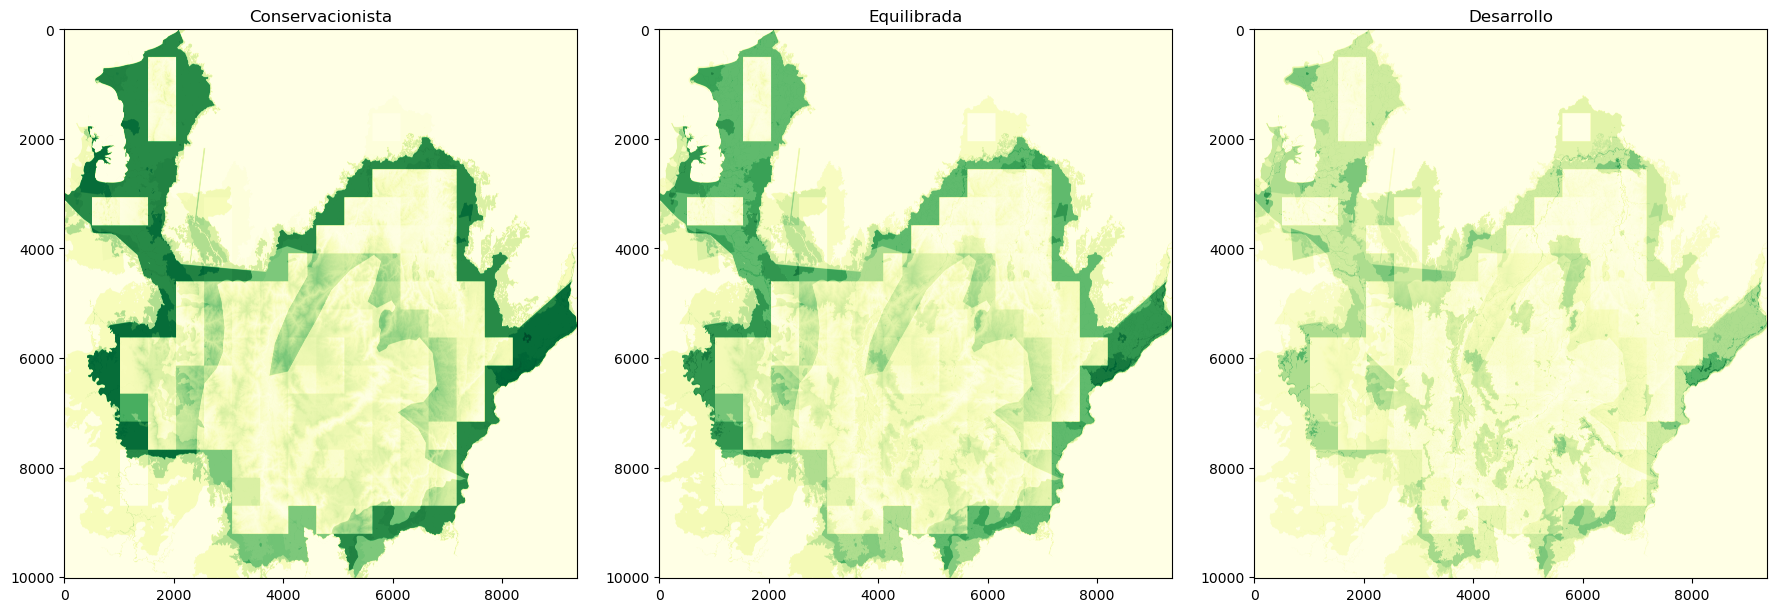

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, (key, val) in enumerate(resultados.items()):
    axes[i].imshow(val, cmap="YlGn")
    axes[i].set_title(key)
plt.tight_layout()
plt.show()

In [ ]:
zonas_altas = [(r > 0.75).astype(int) for r in resultados.values()]
consenso = sum(zonas_altas)
zona_final = (consenso >= 2).astype(int)

plt.imshow(zona_final, cmap="viridis")
plt.title("Área Final Consensuada (≥2 perspectivas)")
plt.colorbar()
plt.show()

En esta primera prueba del análisis multicriterio se generaron mapas de aptitud territorial bajo tres perspectivas: Conservacionista, Equilibrada y de Desarrollo. Los resultados muestran patrones espaciales coherentes, con mayor concentración de áreas altamente aptas en el enfoque conservacionista, una distribución más equilibrada en la segunda, y una mayor fragmentación en la perspectiva orientada al desarrollo. Aunque los bloques procesados por secciones son visibles en los mapas, los resultados permiten identificar zonas clave para la conectividad del jaguar en Antioquia, y sientan las bases para consolidar un mapa integrado y definir la ruta más viable.

# Segunda ruta de trabajo (No definitiva)

Se importan las librerías necesarias para realizar análisis espacial focalizado, identificación de áreas conectadas y operaciones sobre bloques raster.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window
from scipy.ndimage import label, center_of_mass, binary_dilation
from skimage.draw import polygon
import gc

Se define la ruta del raster multibanda, la perspectiva a analizar (Conservacionista) y un diccionario que asocia los nombres de los criterios con el índice de banda correspondiente dentro del stack.

In [2]:
stack_path = "/app/WORKSHOP06/DATOS/stack_unificado.tif"
exportar_solo = "Conservacionista"

bandas_dict = {
    "Areas_Protegidas": 1,
    "CentrosPoblados": 2,
    "Comunidad_Negra_Titulada": 3,
    "Ecosistemas": 4,
    "jaguar_antioquia": 5,
    "Resguardo_Indigena_Formalizado_05": 6,
    "Vias_ant": 7,
    "Zonas_Reservas_Campesinas": 8,
    "DEM": 9,
    "CuerposAgua": 10
}

Se organizan los criterios en tres grupos temáticos: Ecológico, Cultural-Social y Físico-Ambiental, y se definen las ponderaciones específicas para cada uno bajo tres perspectivas analíticas: Conservacionista, Equilibrada y de Desarrollo, lo que permite ajustar el enfoque del análisis según las prioridades territoriales.

In [3]:
criterios = {
    "Ecologia": ["Ecosistemas", "Areas_Protegidas", "jaguar_antioquia"],
    "CulturalSocial": ["Resguardo_Indigena_Formalizado_05", "Comunidad_Negra_Titulada", "Zonas_Reservas_Campesinas", "CentrosPoblados"],
    "FisicoAmbiental": ["DEM", "CuerposAgua", "Vias_ant"]
}

perspectivas = {
    "Conservacionista": {"Ecologia": 0.6, "CulturalSocial": 0.3, "FisicoAmbiental": 0.1},
    "Equilibrada": {"Ecologia": 0.4, "CulturalSocial": 0.3, "FisicoAmbiental": 0.3},
    "Desarrollo": {"Ecologia": 0.2, "CulturalSocial": 0.2, "FisicoAmbiental": 0.6}
}

Se define una función para normalizar los valores de un arreglo, llevando sus datos al rango \[0, 1], lo cual es esencial para asegurar que todos los criterios tengan el mismo peso relativo al combinarlos en el análisis multicriterio.

In [4]:
def normalizar(arr):
    arr = np.nan_to_num(arr, nan=0)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)

Se implementa una función que calcula el mapa de aptitud combinando los criterios definidos en cada tema. Para ello, normaliza las bandas correspondientes, promedia sus valores dentro de cada grupo temático y aplica los pesos definidos por la perspectiva seleccionada, generando un resultado final en formato raster.

In [5]:
def calcular_por_tema(stack_path, criterios, bandas_dict, pesos):
    with rasterio.open(stack_path) as src:
        height, width = src.height, src.width
        resultado = np.zeros((height, width), dtype=np.float32)

        for tema, capas in criterios.items():
            acumulado = []
            for c in capas:
                capa = src.read(bandas_dict[c]).astype(np.float32)
                norm = normalizar(capa)
                acumulado.append(norm)
            promedio = np.mean(acumulado, axis=0)
            resultado += pesos[tema] * promedio
    return resultado

Se calculan los mapas de aptitud para cada una de las perspectivas definidas, aplicando sus respectivas ponderaciones temáticas. Los resultados se almacenan en un diccionario y se libera memoria tras cada iteración para optimizar el uso de recursos.

In [6]:
resultados = {}
for nombre, pesos in perspectivas.items():
    print(f"Procesando perspectiva: {nombre}")
    resultado = calcular_por_tema(stack_path, criterios, bandas_dict, pesos)
    resultados[nombre] = resultado
    gc.collect()

Procesando perspectiva: Conservacionista
Procesando perspectiva: Equilibrada
Procesando perspectiva: Desarrollo


Se extrae la capa correspondiente al hábitat del jaguar desde el stack raster y se binariza para identificar su presencia. Luego, se aplican etiquetas a las manchas conectadas mediante `label`, lo que permite contar e individualizar las distintas áreas donde habita la especie.

In [7]:
with rasterio.open(stack_path) as src:
    jaguar = src.read(bandas_dict["jaguar_antioquia"])

jaguar_bin = (jaguar > 0).astype(np.uint8)
labeled, n_obj = label(jaguar_bin)

Se verifica que existan al menos dos manchas de hábitat del jaguar y, en caso afirmativo, se calculan los centroides de las dos primeras áreas detectadas, que serán utilizados como puntos de inicio y fin para trazar la ruta óptima del corredor ecológico.

In [8]:
if n_obj < 2:
    raise ValueError("Se esperaban al menos 2 manchas de jaguar")

centros = [tuple(map(int, c)) for c in center_of_mass(jaguar_bin, labeled, range(1, n_obj + 1))[:2]]

Se crea una máscara que cubre el área rectangular entre los centroides de las dos manchas principales de jaguar, y luego se expande mediante dilatación morfológica para incluir un entorno más amplio. Esta zona servirá como área de análisis restringida para definir la ruta ecológica óptima.

In [9]:
mask = np.zeros_like(jaguar, dtype=np.uint8)
rr, cc = polygon([centros[0][0], centros[0][0], centros[1][0], centros[1][0]],
                 [centros[0][1], centros[1][1], centros[1][1], centros[0][1]])
mask[rr, cc] = 1
mask = binary_dilation(mask, iterations=25).astype(np.uint8)

Se calcula un mapa promedio de aptitud dentro del área definida por la máscara, combinando los valores obtenidos en las distintas perspectivas. El resultado (`decision_final`) representa una síntesis de las zonas más aptas para el corredor ecológico entre las manchas de jaguar, considerando únicamente los píxeles dentro del área de interés.

In [10]:
zona_final = np.zeros_like(mask, dtype=np.float32)
conteo = np.zeros_like(mask, dtype=np.float32)

for nombre, apt in resultados.items():
    zona = np.where(mask, apt, 0)
    zona_final += zona
    conteo += (zona > 0).astype(np.float32)

decision_final = np.where(conteo > 0, zona_final / conteo, np.nan)

/tmp/ipykernel_8335/2234901089.py:9: RuntimeWarning: invalid value encountered in divide
  decision_final = np.where(conteo > 0, zona_final / conteo, np.nan)


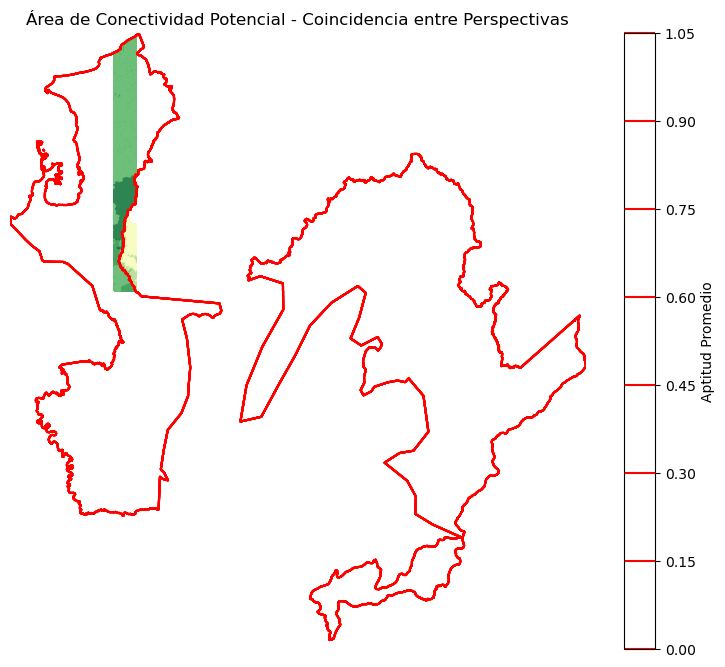

In [11]:
plt.figure(figsize=(10, 8))
plt.imshow(decision_final, cmap="YlGn", alpha=0.9)
plt.contour(jaguar_bin, colors="red", linewidths=1.5)
plt.title("Área de Conectividad Potencial - Coincidencia entre Perspectivas")
plt.axis("off")
plt.colorbar(label="Aptitud Promedio")
plt.show()

El resultado muestra el área de conectividad potencial entre las dos manchas principales de hábitat del jaguar, calculada como el promedio de aptitud obtenido a partir de las tres perspectivas analizadas (Conservacionista, Equilibrada y Desarrollo). La franja central en tonos verdes representa los píxeles con mayor aptitud promedio, indicando zonas de mayor consenso para establecer el corredor ecológico. Esta área fue delimitada mediante una máscara rectangular generada entre los centroides de las manchas, posteriormente ampliada por dilatación, lo que permitió enfocar el análisis en la zona clave de conexión. El contorno rojo señala el límite de las manchas originales, y la escala de colores muestra cómo varía la aptitud promedio dentro del área de interés.

# Tercera ruta de trabajo (Definitiva)

In [1]:
# Se corta el stack con un shape de Antioquia para reducir el área de análisis

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, center_of_mass
from skimage.graph import route_through_array

Se define la ruta del raster multibanda correspondiente a la tercera ruta de trabajo y se establece un diccionario que relaciona los nombres de los criterios temáticos con el índice de su respectiva banda dentro del archivo, facilitando su identificación y uso en el análisis posterior.

In [57]:
stack_path = r"C:\Users\juanc\Documents\UN\GEOPROCESAMIENTO\GUIA\mi_proyecto_jupyter\WORKSHOP06\DATOS\stack_unificado_ant.tif"
bandas_dict = {
    "Areas_Protegidas": 1,
    "CentrosPoblados": 2,
    "Comunidad_Negra_Titulada": 3,
    "Ecosistemas": 4,
    "jaguar_antioquia": 5,
    "Resguardo_Indigena_Formalizado_05": 6,
    "Vias_ant": 7,
    "Zonas_Reservas_Campesinas": 8,
    "DEM": 9,
    "CuerposAgua": 10
}

In [59]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

Se define una función de normalización que escala los valores de un arreglo al rango \[0, 1], utilizando únicamente los píxeles válidos (no nulos o infinitos). Esta función permite comparar y combinar criterios en igualdad de condiciones durante el análisis multicriterio.

In [61]:
def normalizar(arr, mask=None):
    mask = np.isfinite(arr) if mask is None else mask
    arr_norm = np.zeros_like(arr, dtype=np.float32)
    arr_masked = arr[mask]
    if arr_masked.size > 0:
        arr_norm[mask] = MinMaxScaler().fit_transform(arr_masked.reshape(-1, 1)).reshape(-1)
    return arr_norm

Se cargan todas las bandas del raster multibanda en un diccionario, asignando a cada una su nombre temático, lo que facilita el acceso directo a cada criterio para su análisis o procesamiento posterior.

In [63]:
with rasterio.open(stack_path) as src:
    bandas = {
        nombre: src.read(idx)
        for nombre, idx in bandas_dict.items()
    }

Se calcula el índice de aptitud para el tema de Ecología combinando tres capas: ecosistemas, áreas protegidas y la presencia del jaguar. Cada capa se normaliza o binariza según corresponda, y luego se pondera con pesos específicos para obtener un mapa integrado de aptitud ecológica.

In [64]:
# 1. TEMA: ECOLOGÍA

ecosistemas = normalizar(bandas["Ecosistemas"])  # Menor distancia = mayor aptitud
areas_protegidas = normalizar(bandas["Areas_Protegidas"])
jaguar_area = bandas["jaguar_antioquia"].astype(bool).astype(int)  # 1 donde hay jaguar

ecologia = (
    ecosistemas * 0.4 +
    areas_protegidas * 0.4 +
    jaguar_area * 0.2
)

Se construye el mapa de aptitud para el tema Cultural y Social, considerando como zonas aptas aquellas que no se superponen con comunidades étnicas ni reservas campesinas, y que además estén alejadas de centros poblados. El resultado es una capa donde se priorizan áreas sin restricciones sociales y con baja presión urbana.

In [67]:
# 2. TEMA: CULTURAL Y SOCIAL

restricciones = (
    (bandas["Resguardo_Indigena_Formalizado_05"] == 0).astype(int) *
    (bandas["Comunidad_Negra_Titulada"] == 0).astype(int) *
    (bandas["Zonas_Reservas_Campesinas"] == 0).astype(int)
)
centros_poblados = 1 - normalizar(bandas["CentrosPoblados"])

cultural_social = restricciones * centros_poblados

Se calcula la aptitud para el tema de Condiciones Físico-Ambientales, considerando zonas con pendientes suaves (≤15%), alturas moderadas, proximidad a cuerpos de agua y alejamiento de vías. Cada factor se normaliza o transforma según su lógica espacial, y luego se combina con ponderaciones específicas para generar un índice compuesto de aptitud física del territorio.

In [69]:
# 3. TEMA: CONDICIONES FÍSICO-AMBIENTALES

# Calcular pendiente
dem = bandas["DEM"]
gy, gx = np.gradient(dem)
pendiente = np.sqrt(gx**2 + gy**2)
pendiente_mask = (pendiente <= 15).astype(int)  # Solo <15%

altura_norm = 1 - normalizar(dem)  # Altura moderada
agua = normalizar(bandas["CuerposAgua"])
vias = 1 - normalizar(bandas["Vias_ant"])  # Mayor distancia = mejor

fisico_ambiental = (
    pendiente_mask * 0.4 +
    altura_norm * 0.2 +
    agua * 0.2 +
    vias * 0.2
)

C:\Users\juanc\AppData\Local\Temp\ipykernel_8224\144458625.py:6: RuntimeWarning: overflow encountered in square
  pendiente = np.sqrt(gx**2 + gy**2)


Se generan tres mapas de aptitud territorial según distintas perspectivas de análisis: Conservacionista, Equilibrada y Precautoria. Cada una combina los temas ecológico, cultural-social y físico-ambiental con diferentes ponderaciones, reflejando así distintos enfoques de priorización en la planificación del corredor ecológico.

In [71]:
# A: Conservacionista
perspectiva_A = ecologia * 0.6 + cultural_social * 0.2 + fisico_ambiental * 0.2

# B: Equilibrada
perspectiva_B = ecologia * 0.33 + cultural_social * 0.33 + fisico_ambiental * 0.33

# C: Precautoria (más restricciones)
perspectiva_C = ecologia * 0.2 + cultural_social * 0.4 + fisico_ambiental * 0.4

Se visualizan los mapas de aptitud correspondientes a los tres temas principales y las tres perspectivas definidas, organizados en una cuadrícula. Esto permite comparar de forma clara cómo varía la aptitud territorial según el enfoque aplicado y los factores considerados en cada caso.

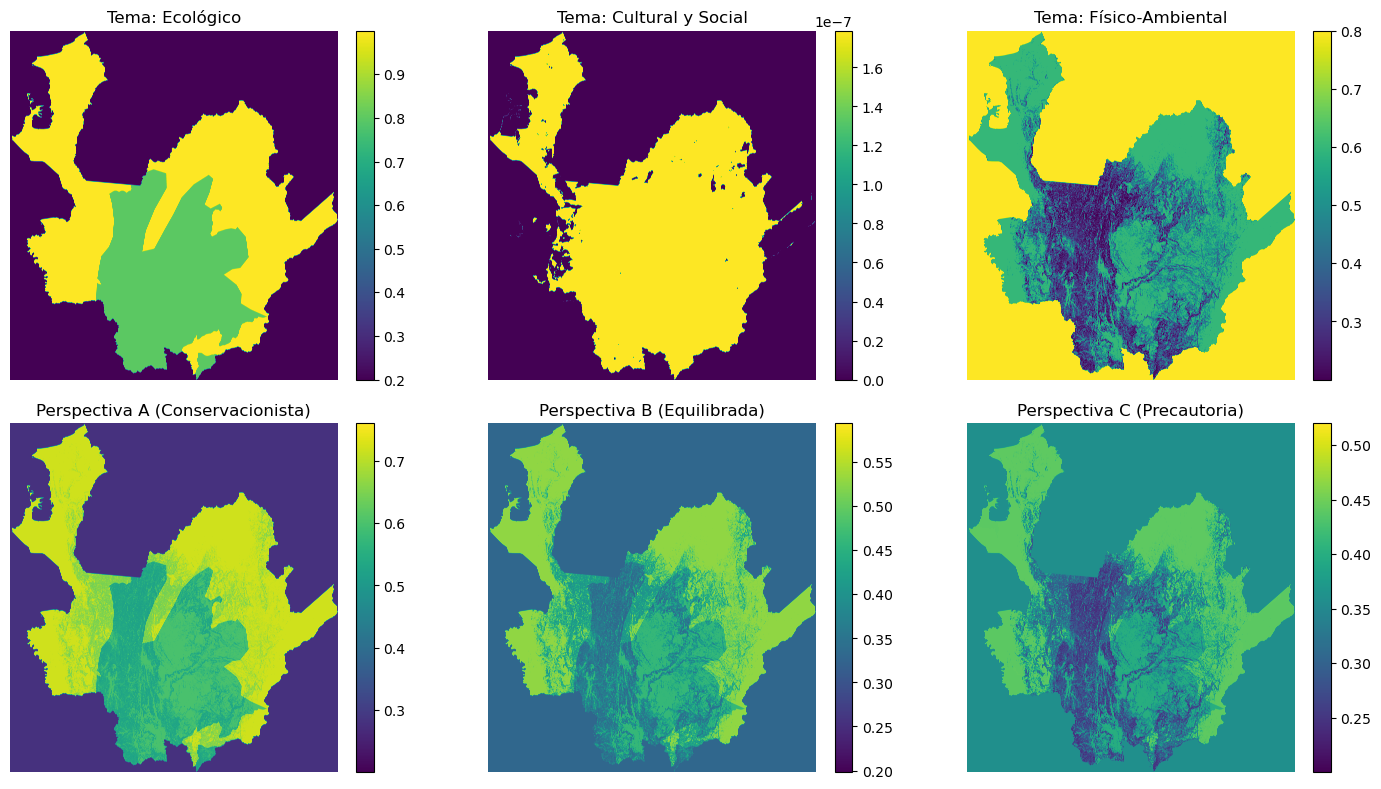

In [73]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.ravel()

for i, (titulo, data) in enumerate([
    ("Tema: Ecológico", ecologia),
    ("Tema: Cultural y Social", cultural_social),
    ("Tema: Físico-Ambiental", fisico_ambiental),
    ("Perspectiva A (Conservacionista)", perspectiva_A),
    ("Perspectiva B (Equilibrada)", perspectiva_B),
    ("Perspectiva C (Precautoria)", perspectiva_C),
]):
    im = axs[i].imshow(data, cmap='viridis')
    axs[i].set_title(titulo)
    axs[i].axis('off')
    fig.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Los resultados del análisis multicriterio muestran la distribución espacial de la aptitud territorial según los tres temas definidos (Ecológico, Cultural-Social y Físico-Ambiental) y las perspectivas aplicadas (Conservacionista, Equilibrada y Precautoria). El mapa ecológico destaca zonas con fuerte presencia del jaguar, áreas protegidas y ecosistemas clave, mientras que el componente físico-ambiental refleja variaciones más detalladas influenciadas por pendiente, cuerpos de agua y vías. El tema cultural-social, en cambio, presenta valores homogéneamente bajos fuera de zonas restringidas. En las perspectivas, se observa que la Conservacionista da mayor peso a las zonas ecológicas centrales, la Equilibrada ofrece una distribución intermedia, y la Precautoria reduce la aptitud al priorizar restricciones sociales y físicas. Estos patrones respaldan una toma de decisiones diferenciada según los objetivos de conservación y uso del territorio.

Se genera un mapa integrado de aptitud (`perspectiva_D`) promediando las tres perspectivas anteriores (Conservacionista, Equilibrada y Precautoria), con el fin de identificar zonas de consenso que representen un equilibrio entre los distintos enfoques analizados.

In [228]:
perspectiva_D = (perspectiva_A + perspectiva_B + perspectiva_C) / 3

Ese fragmento de código generará un mapa de la Perspectiva D (Intersección), que representa el promedio de las tres perspectivas previas. Este enfoque permite visualizar las áreas con mayor consenso en términos de aptitud espacial, integrando criterios ecológicos, culturales-sociales y físico-ambientales de manera balanceada.

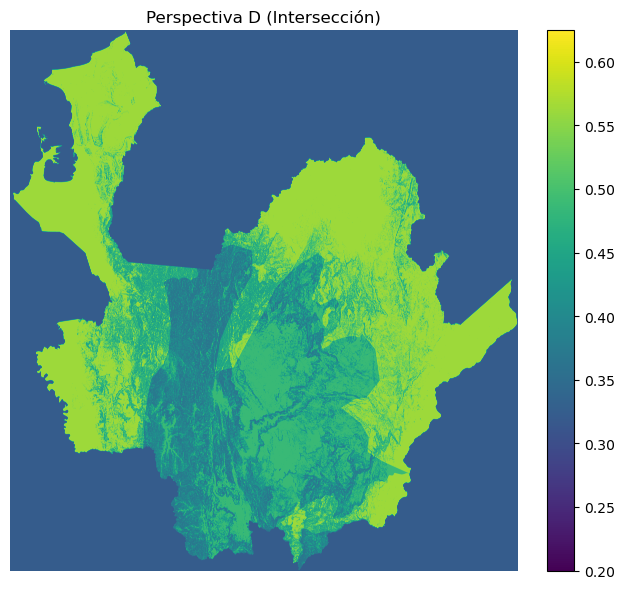

In [171]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(perspectiva_D, cmap='viridis')
ax.set_title("Perspectiva D (Intersección)")
ax.axis('off')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Visualización de la ruta óptima sobre la pespectiva D

Se convierte el mapa de aptitud en un mapa de costo, donde los valores altos de aptitud se transforman en costos bajos para facilitar el cálculo de rutas óptimas.

In [105]:
# Cargar mapa de aptitud (perspectiva_D) y convertir a costo
aptitud = perspectiva_D.copy()
aptitud[~np.isfinite(aptitud)] = 0 

# Convertir a costo: valores altos de aptitud se vuelven bajo costo
epsilon = 1e-6
costo = 1 / (aptitud + epsilon)

In [107]:
import geopandas as gpd
import rasterio
import numpy as np
from shapely.geometry import MultiPolygon
from rasterio.features import rasterize
from scipy.ndimage import label, center_of_mass
from skimage.graph import route_through_array
import matplotlib.pyplot as plt

Se identifican y etiquetan las manchas conectadas en la máscara de presencia del jaguar, permitiendo contar cuántas áreas separadas existen para su posterior análisis.

In [ ]:
from collections import Counter

#Etiquetar manchas
labels, n_labels = label(jaguar_mask)
print(f"Número de manchas encontradas: {n_labels}")

Se cuentan los píxeles de cada mancha identificada y se seleccionan las dos más grandes, que representan las principales áreas de presencia del jaguar a conectar mediante la ruta óptima.

In [158]:
# Contar píxeles por área
unique, counts = np.unique(labels[labels > 0], return_counts=True)
manchas_ordenadas = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)

# Tomar las 2 más grandes
id_m1, id_m2 = manchas_ordenadas[0][0], manchas_ordenadas[1][0]
print(f"Manchas seleccionadas: {id_m1} y {id_m2}")

Manchas seleccionadas: 11 y 2


Se calculan los centroides de las dos manchas principales de jaguar y se utiliza el mapa de costo para trazar la ruta óptima entre ellas, priorizando los píxeles con menor costo (mayor aptitud).

In [162]:
# Centroides de las áreas más grandes
centros = center_of_mass(jaguar_mask, labels, [id_m1, id_m2])
origen = tuple(map(int, centros[0]))  
destino = tuple(map(int, centros[1]))

# Calcular ruta entre las manchas más grandes
ruta, peso = route_through_array(
    costo,
    start=origen,
    end=destino,
    fully_connected=True
)

Se crea una matriz binaria donde los píxeles que conforman la ruta óptima toman el valor 1, permitiendo visualizar y analizar el trayecto resultante.

In [164]:
# Crear un array binario con solo la ruta
ruta_array = np.zeros_like(aptitud)
for r, c in ruta:
    ruta_array[r, c] = 1

# Crear array de la ruta 
ruta_array = np.zeros_like(aptitud)
for r, c in ruta:
    ruta_array[r, c] = 1

Se visualiza el mapa de aptitud con la ruta óptima resaltada en rojo y el área de hábitat del jaguar en naranja. Se incluye una barra de color y una leyenda personalizada para facilitar la interpretación del resultado.

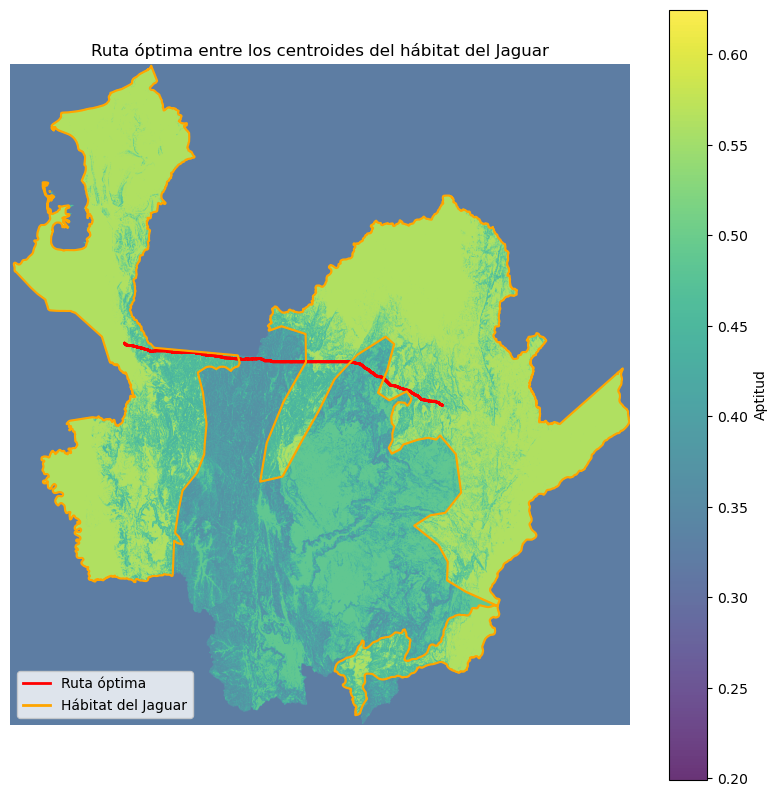

In [166]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.figure(figsize=(10, 10))

# Mostrar mapa de aptitud
im = plt.imshow(aptitud, cmap='viridis', alpha=0.8)

# Dibujar ruta como línea roja
plt.contour(ruta_array, levels=[0.5], colors='red', linewidths=2)

# Dibujar el área de jaguar (en naranja)
plt.contour(jaguar_mask, levels=[0.5], colors="orange", linewidths=1.5)

# Título y colorbar
plt.title("Ruta óptima entre los centroides del hábitat del Jaguar")
plt.axis('off')
cbar = plt.colorbar(im, label='Aptitud')

# Crear leyenda personalizada
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Ruta óptima'),
    Line2D([0], [0], color='orange', lw=2, label='Hábitat del Jaguar')
]
plt.legend(handles=legend_elements, loc='lower left', frameon=True, fontsize='medium')

plt.show()

El mapa final muestra la ruta óptima de conectividad entre las dos manchas principales de hábitat del jaguar, calculada sobre el mapa de aptitud promedio (perspectiva D) que integra criterios ecológicos, culturales y físico-ambientales. La ruta (en rojo) atraviesa zonas con mayor aptitud (colores verdes), evitando áreas restrictivas y priorizando condiciones favorables para el desplazamiento de la especie. Este resultado fue obtenido mediante un análisis de costo mínimo, convirtiendo el mapa de aptitud en un mapa de costos. Entre las tres rutas de trabajo exploradas, esta tercera estrategia (basada en una integración explícita de criterios normalizados y restricciones específica) produjo el resultado más robusto y coherente, generando una ruta continua, ecológicamente viable y alineada con la distribución real del hábitat. Representa así la mejor alternativa para diseñar un corredor ecológico funcional para el jaguar en el área de estudio.

In [143]:
#Extraer valores de aptitud en la ruta
valores_ruta = aptitud[ruta_array == 1]
#Estadísticas descriptivas
print("Estadísticas de aptitud en la ruta:")
print(f"Media: {np.mean(valores_ruta):.3f}")
print(f"Mínimo: {np.min(valores_ruta):.3f}")
print(f"Máximo: {np.max(valores_ruta):.3f}")
print(f"Desviación estándar: {np.std(valores_ruta):.3f}")

Estadísticas de aptitud en la ruta:
Media: 0.508
Mínimo: 0.363
Máximo: 0.563
Desviación estándar: 0.067


La ruta óptima entre las dos manchas principales del hábitat del jaguar presenta una **aptitud media de 0.508**, con valores que oscilan entre **0.363 y 0.563**, y una desviación estándar de **0.067**, lo que indica una trayectoria relativamente estable dentro de áreas de buena idoneidad. Estos resultados evidencian que el corredor propuesto mantiene una conectividad ecológica adecuada y coherente con los criterios definidos, consolidándose como la mejor alternativa generada entre las tres rutas de trabajo analizadas.